
# W04 — Multi-Modal Sensor Benchmark


## Benchmark design

Primary benchmark task: **PATROL vs FAULT**, matching the actual Week 3 CSP/LDA notebooks.

Five modality conditions:

1. IMU-only: `accel_x`, `accel_y`, `accel_z`
2. Motor-current-only: `motor_current`
3. Proximity + RSSI
4. Battery SoC + task success
5. All sensors combined

Five classifiers:

1. Logistic Regression
2. Random Forest
3. Shallow MLP (64 → 32, ReLU)
4. CSP + LDA
5. Gaussian Naive Bayes

All methods use:

- the same fixed-length temporal windows,
- the same 80/20 held-out split,
- the same 5 stratified CV folds.

### Important sampling-rate note

The Week 2 `0–0.5`, `0.5–2`, and `2–5 Hz` band-energy features are valid only for the separate 20 Hz high-frequency stream.  
`proximity`, `rssi`, `battery_soc`, and `task_success` exist only in the 5-minute fleet telemetry, whose Nyquist frequency is far below 0.5 Hz.

Therefore, the **fair five-modality benchmark uses the co-observed 5-minute telemetry** rather than pretending that 0–5 Hz features exist for every modality.

The high-frequency file is still loaded and used in an optional consistency check with the Week 3 signal-processing pipeline.


In [1]:

from pathlib import Path
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import eigh

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


## 1. Load Week 2 data

In [22]:
FLEET_PATH = "../data/robot_sensor_5min.csv"
HF_PATH = "../data/robot_sensor_highfreq.csv"

fleet_df = pd.read_csv(FLEET_PATH)
hf_df = pd.read_csv(HF_PATH)

print("Fleet data:", FLEET_PATH, fleet_df.shape)
print("High-frequency data:", HF_PATH, hf_df.shape)

display(fleet_df.head())
display(hf_df.head())


Fleet data: ../data/robot_sensor_5min.csv (120960, 12)
High-frequency data: ../data/robot_sensor_highfreq.csv (48000, 8)


,timestamp,robot_id,mode,accel_x,accel_y,accel_z,motor_current,proximity,rssi,battery_soc,task_success,imu_magnitude
0,2026-08-10 00:00:00,R01,PATROL,0.181560,-0.022685,9.765057,1.806318,2.234491,-55.888431,93.100778,0,9.766771
1,2026-08-10 00:05:00,R01,PATROL,0.003813,-0.122254,9.707094,2.288695,4.781291,-61.387078,93.089032,1,9.707865
2,2026-08-10 00:10:00,R01,PATROL,0.114086,0.233848,9.832063,2.383943,5.134641,-56.865756,93.065962,1,9.835505
3,2026-08-10 00:15:00,R01,PATROL,0.412985,0.196385,9.728399,2.340912,2.719345,-61.019880,93.026576,1,9.739142
4,2026-08-10 00:20:00,R01,PATROL,0.264022,0.340855,10.063573,2.323048,2.675605,-55.376955,93.016117,1,10.072805


,time,mode,motor_current,accel_x,accel_y,accel_z,imu_magnitude,window_id
0,0.00,PATROL,2.049671,0.060559,0.010018,9.924071,9.924261,0
1,0.05,PATROL,2.050013,-0.042440,-0.003066,9.825160,9.825252,0
2,0.10,PATROL,2.189131,0.131741,0.071587,9.804799,9.805945,0
3,0.15,PATROL,2.330852,0.200482,0.134262,9.774396,9.777374,0
4,0.20,PATROL,2.200534,0.153513,0.121466,9.774075,9.776035,0


In [3]:

required_fleet = [
    "timestamp", "robot_id", "mode",
    "accel_x", "accel_y", "accel_z",
    "motor_current", "proximity", "rssi",
    "battery_soc", "task_success"
]

required_hf = [
    "time", "mode", "window_id",
    "motor_current", "accel_x", "accel_y",
    "accel_z", "imu_magnitude"
]

missing_fleet = [c for c in required_fleet if c not in fleet_df.columns]
missing_hf = [c for c in required_hf if c not in hf_df.columns]

if missing_fleet:
    raise ValueError(f"Missing fleet columns: {missing_fleet}")
if missing_hf:
    raise ValueError(f"Missing high-frequency columns: {missing_hf}")

fleet_df["timestamp"] = pd.to_datetime(fleet_df["timestamp"])

print("Fleet mode counts:")
display(fleet_df["mode"].value_counts())

print("High-frequency windows per mode:")
display(hf_df.groupby("mode")["window_id"].nunique())


Fleet mode counts:


mode
PATROL      96458
CHARGING    17102
ALERT        5244
FAULT        2156
Name: count, dtype: int64

High-frequency windows per mode:


mode
ALERT       20
CHARGING    20
FAULT       20
PATROL      20
Name: window_id, dtype: int64


## 2. Build common temporal windows from 5-minute telemetry

To make modality comparisons fair, every modality uses the **same windows and labels**.

Because Week 3 actually used `PATROL` vs `FAULT`, this notebook keeps that same binary task.

A window is accepted only when:

- all rows belong to the same robot,
- all rows have the same operational mode,
- the window contains the required number of consecutive 5-minute observations.

Using 3 observations gives a 15-minute window and preserves enough FAULT windows for stratified CV.


In [4]:

CLASS_A = "PATROL"
CLASS_B = "FAULT"

WINDOW_SAMPLES = 3  # 15 minutes at 5-min cadence

ALL_SENSOR_CHANNELS = [
    "accel_x", "accel_y", "accel_z",
    "motor_current", "proximity", "rssi",
    "battery_soc", "task_success"
]

MODALITY_CHANNELS = {
    "IMU-only": ["accel_x", "accel_y", "accel_z"],
    "Motor-current-only": ["motor_current"],
    "Proximity+RSSI": ["proximity", "rssi"],
    "Battery+Task": ["battery_soc", "task_success"],
    "All-sensors": ALL_SENSOR_CHANNELS,
}

binary_fleet = fleet_df[
    fleet_df["mode"].isin([CLASS_A, CLASS_B])
].copy()

binary_fleet = binary_fleet.sort_values(["robot_id", "timestamp"]).reset_index(drop=True)


In [5]:

def build_constant_mode_windows(df, channels, window_samples=3):
    windows = []
    labels = []
    metadata = []

    for robot_id, robot_df in df.groupby("robot_id", sort=False):
        robot_df = robot_df.sort_values("timestamp").reset_index(drop=True)

        # identify contiguous runs of identical mode
        run_id = (robot_df["mode"] != robot_df["mode"].shift()).cumsum()

        for _, run in robot_df.groupby(run_id, sort=False):
            mode = run["mode"].iloc[0]

            # non-overlapping windows inside each constant-mode run
            n_full = len(run) // window_samples

            for w in range(n_full):
                chunk = run.iloc[
                    w * window_samples : (w + 1) * window_samples
                ]

                X = chunk[channels].to_numpy(dtype=float).T

                if np.isnan(X).any() or np.isinf(X).any():
                    continue

                windows.append(X)
                labels.append(mode)
                metadata.append({
                    "robot_id": robot_id,
                    "start_time": chunk["timestamp"].iloc[0],
                    "end_time": chunk["timestamp"].iloc[-1],
                    "mode": mode,
                })

    return (
        np.asarray(windows, dtype=float),
        np.asarray(labels),
        pd.DataFrame(metadata),
    )

X_all, y, window_meta = build_constant_mode_windows(
    binary_fleet,
    ALL_SENSOR_CHANNELS,
    window_samples=WINDOW_SAMPLES,
)

print("All-sensor window tensor:", X_all.shape)
print("Class counts:")
display(pd.Series(y).value_counts())

if pd.Series(y).value_counts().min() < 10:
    raise ValueError(
        "Too few windows in one class for stable 5-fold CV. "
        "Reduce WINDOW_SAMPLES."
    )


All-sensor window tensor: (32727, 8, 3)
Class counts:


PATROL    32078
FAULT       649
Name: count, dtype: int64


## 3. One shared 80/20 held-out split

The split is created once and reused for all modality × classifier combinations.


In [6]:

indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

y_train = y[train_idx]
y_test = y[test_idx]

print("Training windows:", len(train_idx))
print("Test windows:", len(test_idx))
print("\nTraining class counts:")
display(pd.Series(y_train).value_counts())
print("Test class counts:")
display(pd.Series(y_test).value_counts())


Training windows: 26181
Test windows: 6546

Training class counts:


PATROL    25662
FAULT       519
Name: count, dtype: int64

Test class counts:


PATROL    6416
FAULT      130
Name: count, dtype: int64


## 4. Feature representation for classical models

For Logistic Regression, Random Forest, MLP, and Naive Bayes, each temporal window is flattened.

This keeps the preprocessing identical across modalities: the only thing that changes is which sensor channels are included.


In [7]:

channel_to_idx = {c: i for i, c in enumerate(ALL_SENSOR_CHANNELS)}

def select_modality_windows(X, modality):
    idx = [channel_to_idx[c] for c in MODALITY_CHANNELS[modality]]
    return X[:, idx, :]

def flatten_windows(X):
    return X.reshape(X.shape[0], -1)

for modality in MODALITY_CHANNELS:
    X_mod = select_modality_windows(X_all, modality)
    print(
        f"{modality:22s} raw={X_mod.shape}, "
        f"flattened={flatten_windows(X_mod).shape}"
    )


IMU-only               raw=(32727, 3, 3), flattened=(32727, 9)
Motor-current-only     raw=(32727, 1, 3), flattened=(32727, 3)
Proximity+RSSI         raw=(32727, 2, 3), flattened=(32727, 6)
Battery+Task           raw=(32727, 2, 3), flattened=(32727, 6)
All-sensors            raw=(32727, 8, 3), flattened=(32727, 24)


## 5. Shallow PyTorch MLP

In [8]:

class TorchMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        hidden1=64,
        hidden2=32,
        lr=1e-3,
        epochs=40,
        batch_size=64,
        random_state=42,
    ):
        self.hidden1 = hidden1
        self.hidden2 = hidden2
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state

    def fit(self, X, y):
        np.random.seed(self.random_state)
        torch.manual_seed(self.random_state)

        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y)

        self.classes_, y_encoded = np.unique(y, return_inverse=True)

        self.scaler_ = StandardScaler()
        Xs = self.scaler_.fit_transform(X).astype(np.float32)

        self.model_ = nn.Sequential(
            nn.Linear(Xs.shape[1], self.hidden1),
            nn.ReLU(),
            nn.Linear(self.hidden1, self.hidden2),
            nn.ReLU(),
            nn.Linear(self.hidden2, len(self.classes_)),
        )

        ds = TensorDataset(
            torch.tensor(Xs, dtype=torch.float32),
            torch.tensor(y_encoded, dtype=torch.long),
        )
        loader = DataLoader(
            ds,
            batch_size=self.batch_size,
            shuffle=True
        )

        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)

        self.model_.train()
        for _ in range(self.epochs):
            for xb, yb in loader:
                optimizer.zero_grad()
                logits = self.model_(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        Xs = self.scaler_.transform(X).astype(np.float32)

        self.model_.eval()
        with torch.no_grad():
            logits = self.model_(
                torch.tensor(Xs, dtype=torch.float32)
            )
            pred_idx = logits.argmax(dim=1).cpu().numpy()

        return self.classes_[pred_idx]


def make_models(seed=SEED):
    return {
        "Logistic Regression": Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                random_state=seed
            )),
        ]),
        "Random Forest": RandomForestClassifier(
            n_estimators=250,
            random_state=seed,
            class_weight="balanced",
            n_jobs=-1,
        ),
        "Shallow MLP": TorchMLPClassifier(
            hidden1=64,
            hidden2=32,
            lr=1e-3,
            epochs=40,
            batch_size=64,
            random_state=seed,
        ),
        "Naive Bayes": GaussianNB(),
    }



## 6. CSP + LDA — adapted directly from Week 3

The implementation follows the Week 3 steps:

1. fit channel scaler on training windows only,
2. compute normalized class covariance matrices,
3. solve the generalized eigenvalue problem,
4. take CSP spatial filters,
5. compute log-variance CSP features,
6. train LDA.

For a one-channel modality such as motor-current-only, the CSP transform degenerates to a single log-variance feature; the notebook still evaluates it, but the spatial-filter interpretation is limited.


In [9]:

def fit_channel_scaler(X):
    all_samples = np.transpose(X, (0, 2, 1)).reshape(-1, X.shape[1])
    mean = all_samples.mean(axis=0)
    std = all_samples.std(axis=0)
    std[std == 0] = 1.0
    return mean, std

def apply_channel_scaler(X, mean, std):
    return (X - mean[None, :, None]) / std[None, :, None]

def normalized_covariance(X, eps=1e-12):
    X_centered = X - X.mean(axis=1, keepdims=True)
    C = X_centered @ X_centered.T
    tr = np.trace(C)
    return C / (tr + eps)

def mean_class_covariance(X_class):
    return np.mean(
        [normalized_covariance(X) for X in X_class],
        axis=0
    )

def fit_csp(R1, R2, n_pairs=2, eps=1e-8):
    n_channels = R1.shape[0]

    # one-channel case
    if n_channels == 1:
        return np.ones((1, 1))

    n_pairs = min(n_pairs, max(1, n_channels // 2))

    R1_reg = R1 + eps * np.eye(n_channels)
    R2_reg = R2 + eps * np.eye(n_channels)

    eigvals, eigvecs = eigh(R1_reg, R2_reg)
    order = np.argsort(eigvals)[::-1]

    eigvecs = eigvecs[:, order]

    selected = list(range(n_pairs)) + list(
        range(n_channels - n_pairs, n_channels)
    )
    selected = list(dict.fromkeys(selected))

    W = eigvecs[:, selected].T
    W = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-12)

    return W

def csp_logvar_features(X_windows, W, eps=1e-12):
    rows = []

    for X in X_windows:
        Z = W @ X
        variances = np.var(Z, axis=1, ddof=1)

        if len(variances) == 1:
            rows.append(np.log(variances + eps))
        else:
            relative_var = variances / (variances.sum() + eps)
            rows.append(np.log(relative_var + eps))

    return np.asarray(rows)

def fit_predict_csp_lda(X_train_raw, y_train, X_eval_raw):
    mean, std = fit_channel_scaler(X_train_raw)

    Xtr = apply_channel_scaler(X_train_raw, mean, std)
    Xev = apply_channel_scaler(X_eval_raw, mean, std)

    R1 = mean_class_covariance(Xtr[y_train == CLASS_A])
    R2 = mean_class_covariance(Xtr[y_train == CLASS_B])

    W = fit_csp(R1, R2, n_pairs=2)

    Xtr_csp = csp_logvar_features(Xtr, W)
    Xev_csp = csp_logvar_features(Xev, W)

    lda = LinearDiscriminantAnalysis()
    lda.fit(Xtr_csp, y_train)

    return lda.predict(Xev_csp), (mean, std, W, lda)


## 7. Five modalities × five classifiers

In [10]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

cv_rows = []
test_rows = []
fitted_models = {}

for modality in MODALITY_CHANNELS:
    print("Running:", modality)

    X_mod_raw = select_modality_windows(X_all, modality)
    X_mod_flat = flatten_windows(X_mod_raw)

    X_train_raw = X_mod_raw[train_idx]
    X_test_raw = X_mod_raw[test_idx]

    X_train_flat = X_mod_flat[train_idx]
    X_test_flat = X_mod_flat[test_idx]

    # 4 classical / feature-vector models
    for model_name in make_models().keys():
        for fold, (tr, va) in enumerate(
            cv.split(X_train_flat, y_train),
            start=1
        ):
            model = make_models(seed=SEED + fold)[model_name]
            model.fit(X_train_flat[tr], y_train[tr])
            pred = model.predict(X_train_flat[va])

            cv_rows.append({
                "Modality": modality,
                "Classifier": model_name,
                "Fold": fold,
                "Accuracy": accuracy_score(y_train[va], pred),
                "Macro_F1": f1_score(
                    y_train[va],
                    pred,
                    average="macro"
                ),
            })

        final_model = make_models(seed=SEED)[model_name]
        final_model.fit(X_train_flat, y_train)
        test_pred = final_model.predict(X_test_flat)

        test_rows.append({
            "Modality": modality,
            "Classifier": model_name,
            "Test_Accuracy": accuracy_score(y_test, test_pred),
            "Test_Macro_F1": f1_score(
                y_test,
                test_pred,
                average="macro"
            ),
        })

        fitted_models[(modality, model_name)] = (
            final_model,
            X_test_flat,
            test_pred,
        )

    # CSP + LDA
    for fold, (tr, va) in enumerate(
        cv.split(X_train_raw, y_train),
        start=1
    ):
        pred, _ = fit_predict_csp_lda(
            X_train_raw[tr],
            y_train[tr],
            X_train_raw[va],
        )

        cv_rows.append({
            "Modality": modality,
            "Classifier": "CSP + LDA",
            "Fold": fold,
            "Accuracy": accuracy_score(y_train[va], pred),
            "Macro_F1": f1_score(
                y_train[va],
                pred,
                average="macro"
            ),
        })

    test_pred, csp_state = fit_predict_csp_lda(
        X_train_raw,
        y_train,
        X_test_raw,
    )

    test_rows.append({
        "Modality": modality,
        "Classifier": "CSP + LDA",
        "Test_Accuracy": accuracy_score(y_test, test_pred),
        "Test_Macro_F1": f1_score(
            y_test,
            test_pred,
            average="macro"
        ),
    })

    fitted_models[(modality, "CSP + LDA")] = (
        csp_state,
        X_test_raw,
        test_pred,
    )

print("Benchmark complete.")


Running: IMU-only
Running: Motor-current-only
Running: Proximity+RSSI
Running: Battery+Task
Running: All-sensors
Benchmark complete.


## 8. Benchmark table

In [11]:

cv_df = pd.DataFrame(cv_rows)
test_df = pd.DataFrame(test_rows)

cv_summary = (
    cv_df
    .groupby(["Modality", "Classifier"])
    .agg(
        CV_Accuracy_Mean=("Accuracy", "mean"),
        CV_Accuracy_SD=("Accuracy", "std"),
        CV_F1_Mean=("Macro_F1", "mean"),
        CV_F1_SD=("Macro_F1", "std"),
    )
    .reset_index()
)

benchmark = (
    cv_summary
    .merge(
        test_df,
        on=["Modality", "Classifier"],
        how="left"
    )
    .sort_values(
        ["CV_F1_Mean", "Test_Macro_F1"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    benchmark.style.format({
        "CV_Accuracy_Mean": "{:.3f}",
        "CV_Accuracy_SD": "{:.3f}",
        "CV_F1_Mean": "{:.3f}",
        "CV_F1_SD": "{:.3f}",
        "Test_Accuracy": "{:.3f}",
        "Test_Macro_F1": "{:.3f}",
    })
)


,Modality,Classifier,CV_Accuracy_Mean,CV_Accuracy_SD,CV_F1_Mean,CV_F1_SD,Test_Accuracy,Test_Macro_F1
0,All-sensors,Logistic Regression,1.000,0.000,1.000,0.000,1.000,1.000
1,All-sensors,Random Forest,1.000,0.000,1.000,0.000,1.000,1.000
2,Motor-current-only,Naive Bayes,1.000,0.000,1.000,0.000,1.000,1.000
3,Motor-current-only,Shallow MLP,1.000,0.000,1.000,0.000,1.000,1.000
4,All-sensors,Naive Bayes,1.000,0.000,1.000,0.001,1.000,1.000
5,Motor-current-only,Random Forest,1.000,0.000,1.000,0.001,1.000,1.000
6,Motor-current-only,Logistic Regression,1.000,0.000,1.000,0.001,1.000,1.000
7,All-sensors,Shallow MLP,1.000,0.000,0.999,0.001,1.000,0.996
8,IMU-only,Naive Bayes,1.000,0.000,0.995,0.006,1.000,0.996
9,IMU-only,Shallow MLP,0.999,0.000,0.992,0.003,1.000,0.996


In [12]:

pivot_f1 = benchmark.pivot(
    index="Modality",
    columns="Classifier",
    values="CV_F1_Mean",
)

display(pivot_f1.style.format("{:.3f}"))


Classifier,CSP + LDA,Logistic Regression,Naive Bayes,Random Forest,Shallow MLP
Modality,,,,,
All-sensors,0.662,1.000,1.000,1.000,0.999
Battery+Task,0.859,0.868,0.569,0.811,0.845
IMU-only,0.495,0.505,0.995,0.982,0.992
Motor-current-only,0.924,1.000,1.000,1.000,1.000
Proximity+RSSI,0.495,0.959,0.967,0.945,0.951


## 9. Rank sensor modalities by mean CV F1

In [13]:

best_per_modality = (
    benchmark
    .sort_values("CV_F1_Mean", ascending=False)
    .groupby("Modality", as_index=False)
    .first()
    .sort_values("CV_F1_Mean", ascending=False)
    .reset_index(drop=True)
)

display(
    best_per_modality[
        [
            "Modality",
            "Classifier",
            "CV_F1_Mean",
            "CV_F1_SD",
            "Test_Macro_F1",
        ]
    ].style.format({
        "CV_F1_Mean": "{:.3f}",
        "CV_F1_SD": "{:.3f}",
        "Test_Macro_F1": "{:.3f}",
    })
)


,Modality,Classifier,CV_F1_Mean,CV_F1_SD,Test_Macro_F1
0,All-sensors,Logistic Regression,1.000,0.000,1.000
1,Motor-current-only,Naive Bayes,1.000,0.000,1.000
2,IMU-only,Naive Bayes,0.995,0.006,0.996
3,Proximity+RSSI,Naive Bayes,0.967,0.008,0.980
4,Battery+Task,Logistic Regression,0.868,0.013,0.876


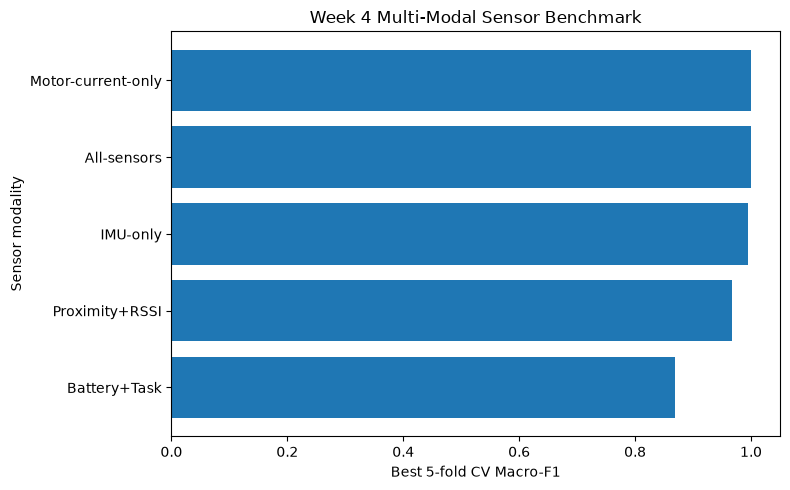

In [14]:

plot_df = best_per_modality.sort_values("CV_F1_Mean")

plt.figure(figsize=(8, 5))
plt.barh(plot_df["Modality"], plot_df["CV_F1_Mean"])
plt.xlabel("Best 5-fold CV Macro-F1")
plt.ylabel("Sensor modality")
plt.title("Week 4 Multi-Modal Sensor Benchmark")
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()


## 10. Held-out test performance of winning combination

In [15]:

winner = best_per_modality.iloc[0]

top_modality = winner["Modality"]
top_classifier = winner["Classifier"]

_, _, top_test_pred = fitted_models[
    (top_modality, top_classifier)
]

print("Top modality:", top_modality)
print("Top classifier:", top_classifier)
print(
    f"CV Macro-F1: "
    f"{winner['CV_F1_Mean']:.3f} ± "
    f"{winner['CV_F1_SD']:.3f}"
)
print(
    f"Held-out Test Macro-F1: "
    f"{winner['Test_Macro_F1']:.3f}"
)

print()
print(classification_report(
    y_test,
    top_test_pred,
    digits=3
))


Top modality: All-sensors
Top classifier: Logistic Regression
CV Macro-F1: 1.000 ± 0.000
Held-out Test Macro-F1: 1.000

              precision    recall  f1-score   support

       FAULT      1.000     1.000     1.000       130
      PATROL      1.000     1.000     1.000      6416

    accuracy                          1.000      6546
   macro avg      1.000     1.000     1.000      6546
weighted avg      1.000     1.000     1.000      6546



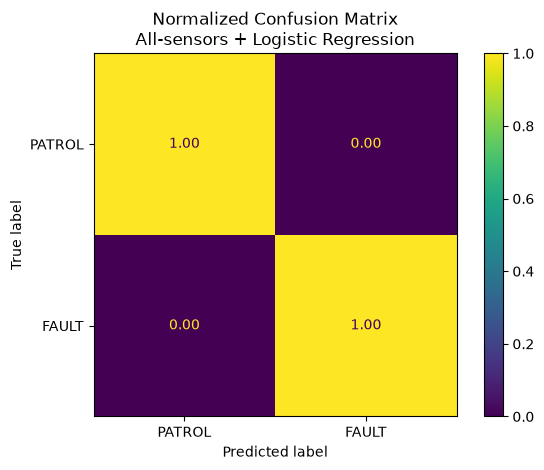

In [16]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    top_test_pred,
    labels=[CLASS_A, CLASS_B],
    normalize="true",
    values_format=".2f",
)

plt.title(
    f"Normalized Confusion Matrix\n"
    f"{top_modality} + {top_classifier}"
)
plt.tight_layout()
plt.show()



## 11. Permutation importance on held-out test data

Permutation importance requires named feature-vector inputs, so within the winning modality we use its best **classical feature-vector model** rather than CSP+LDA.

Feature names encode both sensor channel and position within the 15-minute window.


In [17]:

classical_names = [
    "Logistic Regression",
    "Random Forest",
    "Shallow MLP",
    "Naive Bayes",
]

best_classical = (
    benchmark[
        (benchmark["Modality"] == top_modality)
        & (benchmark["Classifier"].isin(classical_names))
    ]
    .sort_values("CV_F1_Mean", ascending=False)
    .iloc[0]
)

importance_model_name = best_classical["Classifier"]

importance_model, X_importance_test, _ = fitted_models[
    (top_modality, importance_model_name)
]

channels = MODALITY_CHANNELS[top_modality]

feature_names = [
    f"{channel}__t{time_i}"
    for channel in channels
    for time_i in range(WINDOW_SAMPLES)
]

perm = permutation_importance(
    importance_model,
    X_importance_test,
    y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=SEED,
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance_Mean": perm.importances_mean,
    "Importance_SD": perm.importances_std,
}).sort_values(
    "Importance_Mean",
    ascending=False
).reset_index(drop=True)

print("Top modality:", top_modality)
print("Importance model:", importance_model_name)

display(
    importance_df.head(15).style.format({
        "Importance_Mean": "{:.4f}",
        "Importance_SD": "{:.4f}",
    })
)


Top modality: All-sensors
Importance model: Logistic Regression


,Feature,Importance_Mean,Importance_SD
0,motor_current__t2,0.0159,0.0030
1,motor_current__t0,0.0148,0.0037
2,motor_current__t1,0.0104,0.0018
3,accel_x__t0,0.0000,0.0000
4,proximity__t2,0.0000,0.0000
5,task_success__t1,0.0000,0.0000
6,task_success__t0,0.0000,0.0000
7,battery_soc__t2,0.0000,0.0000
8,battery_soc__t1,0.0000,0.0000
9,battery_soc__t0,0.0000,0.0000


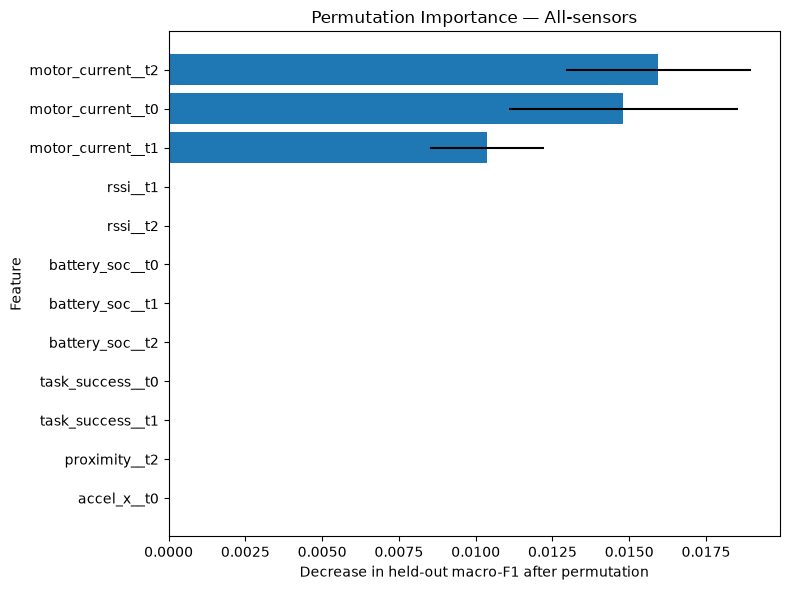

In [18]:

top_imp = importance_df.head(12).sort_values("Importance_Mean")

plt.figure(figsize=(8, 6))
plt.barh(
    top_imp["Feature"],
    top_imp["Importance_Mean"],
    xerr=top_imp["Importance_SD"],
)
plt.xlabel("Decrease in held-out macro-F1 after permutation")
plt.ylabel("Feature")
plt.title(f"Permutation Importance — {top_modality}")
plt.tight_layout()
plt.show()



## 12. Optional high-frequency consistency check

This does **not** enter the five-modality ranking because the high-frequency dataset does not contain proximity, RSSI, battery, or task-success channels.

It simply confirms that the Week 3 high-frequency structure is still available and can be reused later.


In [19]:

HF_CHANNELS = [
    "motor_current",
    "accel_x",
    "accel_y",
    "accel_z",
    "imu_magnitude",
]

hf_binary = hf_df[
    hf_df["mode"].isin([CLASS_A, CLASS_B])
].copy()

def build_hf_tensor(data, channels):
    windows = []
    labels = []

    for (mode, window_id), group in data.groupby(
        ["mode", "window_id"],
        sort=False
    ):
        group = group.sort_values("time")
        windows.append(
            group[channels].to_numpy(dtype=float).T
        )
        labels.append(mode)

    return np.asarray(windows), np.asarray(labels)

X_hf, y_hf = build_hf_tensor(
    hf_binary,
    HF_CHANNELS,
)

print("High-frequency Week 3-compatible tensor:", X_hf.shape)
print(pd.Series(y_hf).value_counts())


High-frequency Week 3-compatible tensor: (40, 5, 600)
PATROL    20
FAULT     20
Name: count, dtype: int64


## 13. Headline statements for the Week 4 recap / midpoint review

In [23]:
winner = best_per_modality.iloc[0]
runner_up = best_per_modality.iloc[1]

gap = winner["CV_F1_Mean"] - runner_up["CV_F1_Mean"]

print(
    f"Best-performing modality/model combination: "
    f"{winner['Modality']} using {winner['Classifier']}, "
    f"with 5-fold CV macro-F1 = "
    f"{winner['CV_F1_Mean']:.3f} ± {winner['CV_F1_SD']:.3f}."
)

# Handle ties correctly
if np.isclose(gap, 0.0, atol=1e-6):
    print(
        f"{winner['Modality']} and {runner_up['Modality']} "
        f"tied for the highest CV macro-F1 "
        f"({winner['CV_F1_Mean']:.3f})."
    )
else:
    print(
        f"It exceeded the second-ranked modality "
        f"({runner_up['Modality']}) by {gap:.3f} macro-F1."
    )

print(
    f"The winning combination achieved held-out test "
    f"macro-F1 = {winner['Test_Macro_F1']:.3f}."
)

if len(importance_df):
    print(
        f"The most influential held-out feature within "
        f"{top_modality} was "
        f"{importance_df.iloc[0]['Feature']}."
    )

Best-performing modality/model combination: All-sensors using Logistic Regression, with 5-fold CV macro-F1 = 1.000 ± 0.000.
All-sensors and Motor-current-only tied for the highest CV macro-F1 (1.000).
The winning combination achieved held-out test macro-F1 = 1.000.
The most influential held-out feature within All-sensors was motor_current__t2.


## Conclusion and Methodological Note

The multi-modal benchmark compared five sensor modality conditions using the
same train/test split and five-fold stratified cross-validation. Performance
was evaluated using both accuracy and macro-F1 to account for the imbalance
between PATROL and FAULT windows.

The strongest modality/model combinations achieved near-perfect or perfect
classification on the synthetic dataset. This result should be interpreted
in the context of the data-generation process: the simulated operational
states were designed with distinct sensor signatures, making PATROL and
FAULT highly separable. Therefore, the benchmark demonstrates the ability
of the pipeline to recover informative sensor-state relationships, rather
than implying equivalent performance on real-world robot telemetry.

The five-modality comparison uses the co-observed 5-minute telemetry rather
than applying the Week 2 frequency bands to every sensor. The 5-minute
sampling interval cannot resolve the 0–0.5 Hz, 0.5–2 Hz, and 2–5 Hz bands.
Those frequency-domain features remain valid for the separate 20 Hz
high-frequency dataset used in the Week 2 PSD analysis and Week 3 CSP/LDA
pipeline.